In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load all countries

In [48]:
all_dfs = []
for country, path in files.items():
    df = pd.read_csv(path)
    
    df.columns = df.columns.str.upper()
    
    df['COUNTRY'] = country

    if 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    elif {'YEAR', 'DOY'}.issubset(df.columns):
        df['DATE'] = pd.to_datetime(
            df['YEAR'].astype(int).astype(str) +
            df['DOY'].astype(int).astype(str).str.zfill(3),
            format='%Y%j',
            errors='coerce'
        )
    elif {'YEAR', 'MONTH'}.issubset(df.columns):
        df['DATE'] = pd.to_datetime(
            df['YEAR'].astype(int).astype(str) + '-' +
            df['MONTH'].astype(int).astype(str).str.zfill(2) + '-01',
            errors='coerce'
        )
    else:
        raise ValueError(f"Could not parse a date column in {path}")

    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

df_all['YEAR'] = df_all['DATE'].dt.year

print(df_all.head())

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M   COUNTRY       DATE  MONTH  
0      5.07  77.13  4.00  Ethiopia 2015-01-01    NaN  
1      4.19  77.14  3.35  Ethiopia 2015-01-02    NaN  
2      2.76  77.11  3.43  Ethiopia 2015-01-03    NaN  
3      1.28  77.07  4.60  Ethiopia 2015-01-04    NaN  
4      2.14  77.01  5.58  Ethiopia 2015-01-05    NaN  


Temperature Trend Comparison

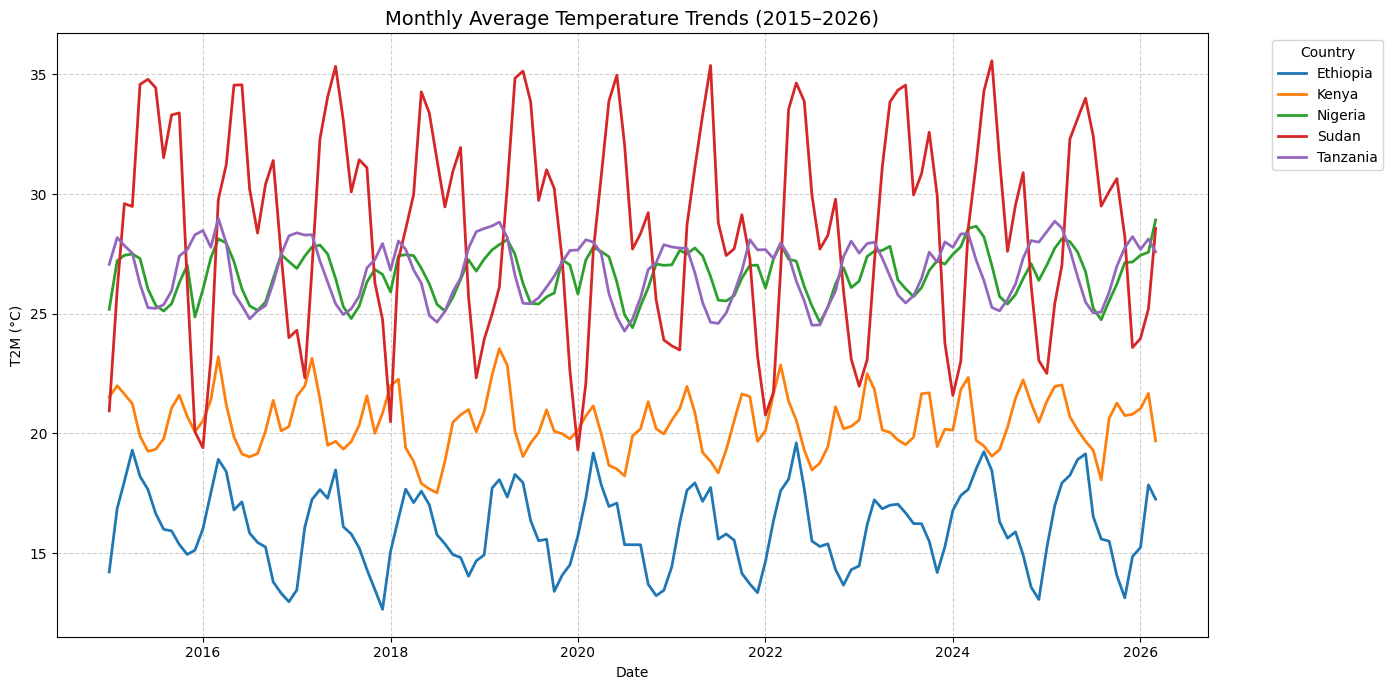

--- Temperature Summary Statistics ---


,Mean_T2M,Median_T2M,StdDev_T2M
COUNTRY,,,
Ethiopia,16.069,16.04,1.898
Kenya,20.427,20.36,1.438
Nigeria,26.659,26.82,1.115
Sudan,28.760,29.16,4.679
Tanzania,26.802,26.99,1.325


In [51]:
# Prepare Monthly Data for cleaner plotting
df_all['MONTH_YEAR'] = df_all['DATE'].dt.to_period('M').dt.to_timestamp()
monthly_temp = df_all.groupby(['COUNTRY', 'MONTH_YEAR'])['T2M'].mean().reset_index()

# Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_temp, x='MONTH_YEAR', y='T2M', hue='COUNTRY', linewidth=2)
plt.title('Monthly Average Temperature Trends (2015–2026)', fontsize=14)
plt.ylabel('T2M (°C)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary Table for T2M
temp_summary = df_all.groupby('COUNTRY')['T2M'].agg(['mean', 'median', 'std']).rename(
    columns={'mean': 'Mean_T2M', 'median': 'Median_T2M', 'std': 'StdDev_T2M'}
).round(3)

print("--- Temperature Summary Statistics ---")
display(temp_summary)

Line plot (ALL countries)

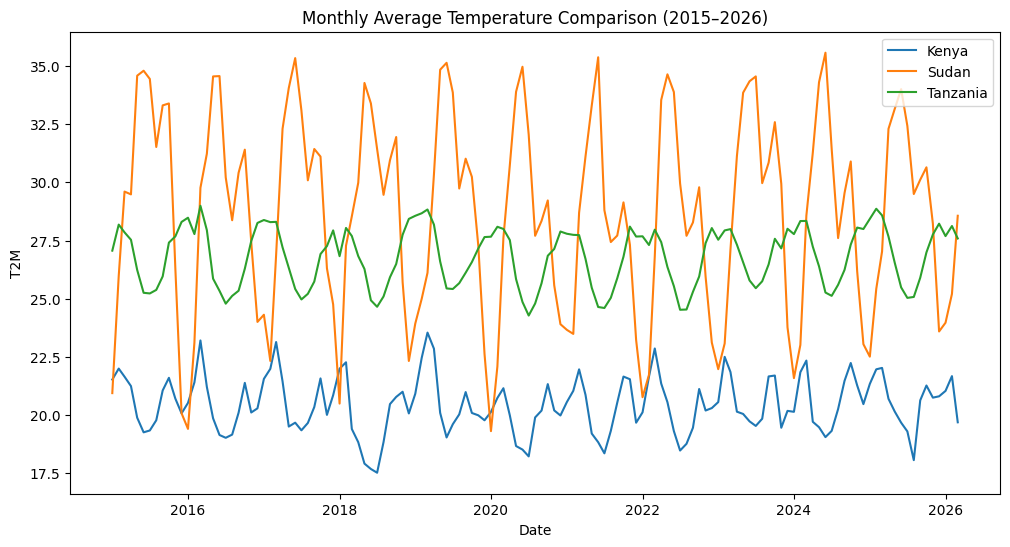

In [27]:
plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Date"], data["T2M"], label=country)

plt.legend()
plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Date")
plt.ylabel("T2M")
plt.show()

Summary table (T2M)

In [21]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Kenya,20.427475,20.36,1.438236
Nigeria,26.659226,26.82,1.114991
Sudan,28.759607,29.16,4.679431
Tanzania,26.802458,26.99,1.325279


Precipitation Variability Comparison

C:\Users\HP\AppData\Local\Temp\ipykernel_25216\706487531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='COUNTRY', y='PRECTOTCORR', palette='viridis')


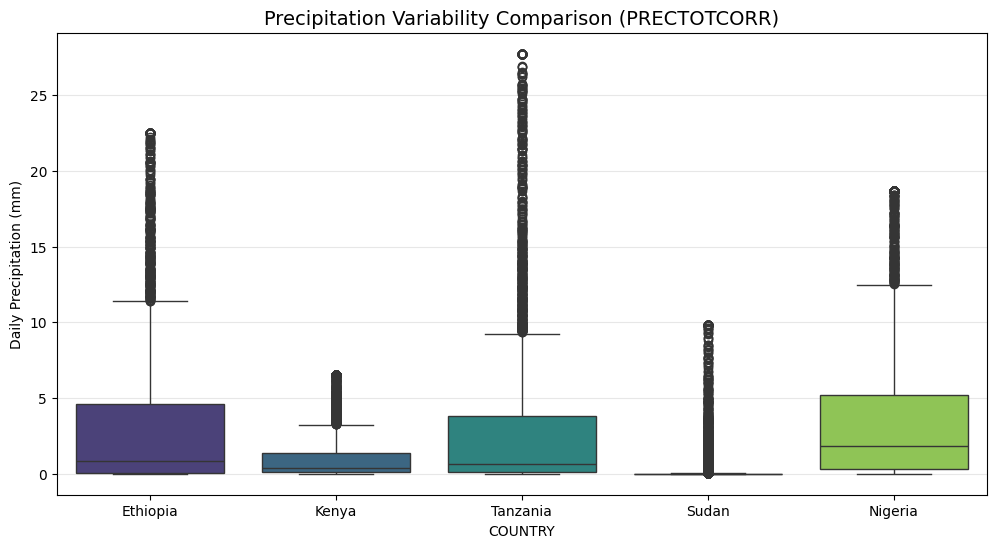

--- Precipitation Summary Statistics ---


,Mean_Precip,Median_Precip,StdDev_Precip
COUNTRY,,,
Ethiopia,3.441,0.82,5.375
Kenya,1.175,0.38,1.750
Nigeria,3.764,1.84,4.794
Sudan,0.487,0.00,1.666
Tanzania,3.421,0.64,6.002


In [52]:
# Side-by-side Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all, x='COUNTRY', y='PRECTOTCORR', palette='viridis')
plt.title('Precipitation Variability Comparison (PRECTOTCORR)', fontsize=14)
plt.ylabel('Daily Precipitation (mm)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Summary Table for Precipitation
precip_summary = df_all.groupby('COUNTRY')['PRECTOTCORR'].agg(['mean', 'median', 'std']).rename(
    columns={'mean': 'Mean_Precip', 'median': 'Median_Precip', 'std': 'StdDev_Precip'}
).round(3)

print("--- Precipitation Summary Statistics ---")
display(precip_summary)

Extreme Event Frequency

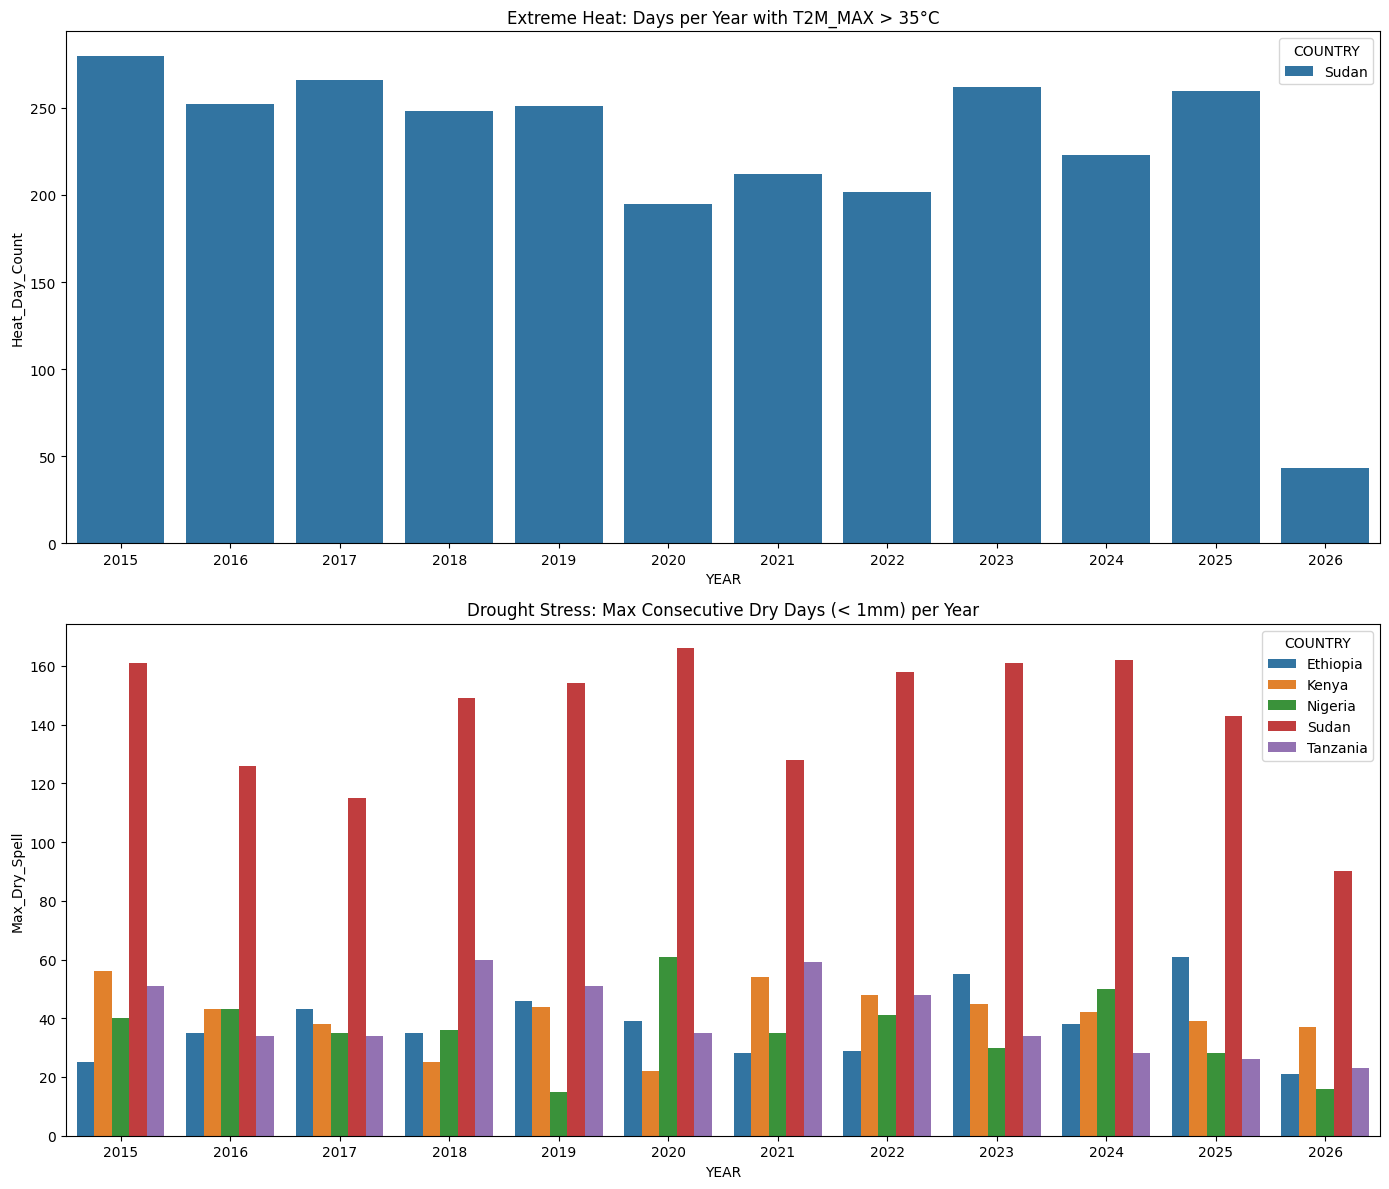

In [ ]:
# 1. Extreme Heat Count (>35°C)
heat_days = df_all[df_all['T2M_MAX'] > 35].groupby(['COUNTRY', 'YEAR']).size().reset_index(name='Heat_Day_Count')

# 2. Consecutive Dry Days (< 1mm)
def max_consecutive_dry(series):
    is_dry = series < 1
    return (is_dry != is_dry.shift()).cumsum()[is_dry].value_counts().max() if is_dry.any() else 0

dry_spells = df_all.groupby(['COUNTRY', 'YEAR'])['PRECTOTCORR'].apply(max_consecutive_dry).reset_index(name='Max_Dry_Spell')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(data=heat_days, x='YEAR', y='Heat_Day_Count', hue='COUNTRY', ax=ax1)
ax1.set_title('Extreme Heat: Days per Year with T2M_MAX > 35°C')

sns.barplot(data=dry_spells, x='YEAR', y='Max_Dry_Spell', hue='COUNTRY', ax=ax2)
ax2.set_title('Drought Stress: Max Consecutive Dry Days (< 1mm) per Year')

plt.tight_layout()
plt.show()

Statistical Testing (ANOVA)

In [55]:
# Remove NaNs before testing to prevent crash
clean_data = df_all.dropna(subset=['T2M'])

# Group T2M by country
country_groups = [group['T2M'].values for name, group in clean_data.groupby('COUNTRY')]

# One-way ANOVA
f_stat, p_val = stats.f_oneway(*country_groups)

print(f"--- Statistical Significance Test (ANOVA) ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Significant climate differences exist between the five countries.")
else:
    print("Result: No statistically significant difference in temperature trends.")

--- Statistical Significance Test (ANOVA) ---
F-statistic: 18970.2514
p-value: 0.0000e+00
Result: Significant climate differences exist between the five countries.


## Final COP32 Climate Vulnerability Assessment

| Rank | Country | Why it is most vulnerable |
|---|---|---|
| 1 | Kenya | Highest combined climate vulnerability from warming trend, precipitation instability, and drought exposure |
| 2 | Sudan | Most extreme heat day count and longest dry spells, signaling acute climate stress |
| 3 | Ethiopia | Strong warming plus high precipitation variability create a compound vulnerability profile |
| 4 | Tanzania | Moderate warming with very unstable rainfall, raising flood/drought trade-off risks |
| 5 | Nigeria | Fast warming but relatively lower drought spell severity in this dataset |

- **Which country is warming fastest and what does the trend suggest?** Nigeria has the steepest warming trend, but Kenya also shows a strong and accelerating rise in mean temperature. This suggests both countries are experiencing rapidly increasing heat pressure, with Nigeria leading the regional warming signal.
- **Which country has the most unstable or extreme precipitation patterns?** Tanzania has the most unstable rainfall variance, while Ethiopia also shows very high precipitation variability. These patterns suggest growing seasonal unpredictability for agriculture and water management.
- **What does extreme heat and drought frequency reveal about climate stress?** Sudan clearly stands out for climate stress: it has the highest number of extreme heat days and the longest consecutive dry spells, indicating severe warming combined with persistent drought risk.
- **How does Ethiopia's climate profile compare to its neighbors?** Ethiopia is among the most vulnerable neighbors because it combines a strong warming trend with high precipitation variability. It is more exposed to compound heat-plus-rainfall instability than Kenya or Nigeria, even if it does not have the single highest count of heat days.
- **Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?** Ethiopia should champion **Kenya** for priority climate finance, because Kenya ranks highest in this combined vulnerability assessment. The data show Kenya is already under strong warming pressure and faces significant rainfall variability and drought exposure, making it a clear regional leader for urgent adaptation support.